Adding physical features 

# Changes from version 1:

## Background GOAL - focus on capturing event onsets
GOAL 1 - fit model on active times only

GOAL 2 - extend input data to additional solar wind features (suggestion: add Bz, Flow Speed, Temperature)

GOAL 3 - regularize model with lasso so that it can learn what lag context is relevant

Question for literature it a good chice to have models that “wait until event peaks in the solar wind” to get a good decay prediction? - because it seems like this that decay is already happening in orbit (when Bz is minimum, satellite already decayed by quite some amount).

## Details:
### GOAL 1:
- train only on active times (can be kp > 4, or surroundings of ICME arrivals)
    - why?
        - as we expect that data to be more meaningful - an actual causal relationship between inputs and target (more or less)
    - expectation?
        - captures onsets better, improvement in metrics (to be confirmed)
        - faster convergence
    - concerns?
        - if going for ICME filtering:
            - when Bz > 0, no effect should be seen;
                -  model might or might not understand this depending on how much data it sees.
        - if going for decay-rependent or kp-dependent, it may be easier for the model to grasp conditional impacts
        - neeed enough active time data to avoid overfitting
### GOAL 3:
- apply a more robust regularizer (either Lasso or MultiTaskElasticNet)
    - why?
        - so that the flexible temporal context can be decided by the model via regularization
        - would avoid manual selection of windows that are important (e.g. input sampling)
    - expectation?
        - captures onsets better or improvement in metrics (especially for short horizons) - it’s okay to fit for 12-h ahead prediction but compute performance metrics for 1-5 hours ahead.
    - concerns?
        - once trained, the fixed coefficients impose a fixed temporal context (just automatically inferred from the data)
        - more compute power needed, especially for CV - recommended: try regular Lasso with manually set alpha e.g. 0.1-0.3 and fitting on a subset

# Load Data

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from utils.data_loader import load_parquet
import numpy as np
from utils.modeling import statistics, make_lags, make_multistep_target, aggregate_multistep_predictions

# Load only specific columns needed for analysis
columns_needed = ['time', 'orbital_decay', '|avg B|', 'F10.7 (LASP)', 'Bz GSE', 'Flow Speed (km/s', 'Temperature (K)', 'Kp (LASP)']

GFOC_data = load_parquet(columns=columns_needed)
print(GFOC_data.head())

✅ Successfully loaded data with shape: (3157920, 8)
                 time  orbital_decay   |avg B|  F10.7 (LASP)    Bz GSE  \
0 2023-01-01 00:00:00        16.6730  5.630000         153.0 -0.960000   
1 2023-01-01 00:00:20        16.6730  5.633333         153.0 -0.426667   
2 2023-01-01 00:00:40        16.6735  5.636667         153.0  0.106667   
3 2023-01-01 00:01:00        16.6740  5.640000         153.0  0.640000   
4 2023-01-01 00:01:20        16.6740  5.633333         153.0  0.190000   

   Flow Speed (km/s  Temperature (K)  Kp (LASP)  
0        595.600000          80634.0      2.333  
1        595.600000          80634.0      2.333  
2        595.600000          80634.0      2.333  
3        595.600000          80634.0      2.333  
4        593.066667          82111.0      2.333  


# 1. Select a subset

In [2]:
from utils.plot_loader import create_subset
# =========================== Input ===================================
start_date = '2024-08-01 00:00:00'
end_date = '2024-10-15 00:00:00'
# =====================================================================

subset = create_subset(GFOC_data, start_date, end_date, resample_rate='5min') #'20s'

dt_seconds = (subset.index[1] - subset.index[0]).total_seconds()
subset['od_daily_mean'] = subset['orbital_decay'].rolling('1D').mean()

## GOAL 1: select active times

Percentage of active times (Kp >= 4): 17.27%
Percentage of times with Bz <= 0: 52.69%
overlap active times and Bz <= 0: 12.573491967964445


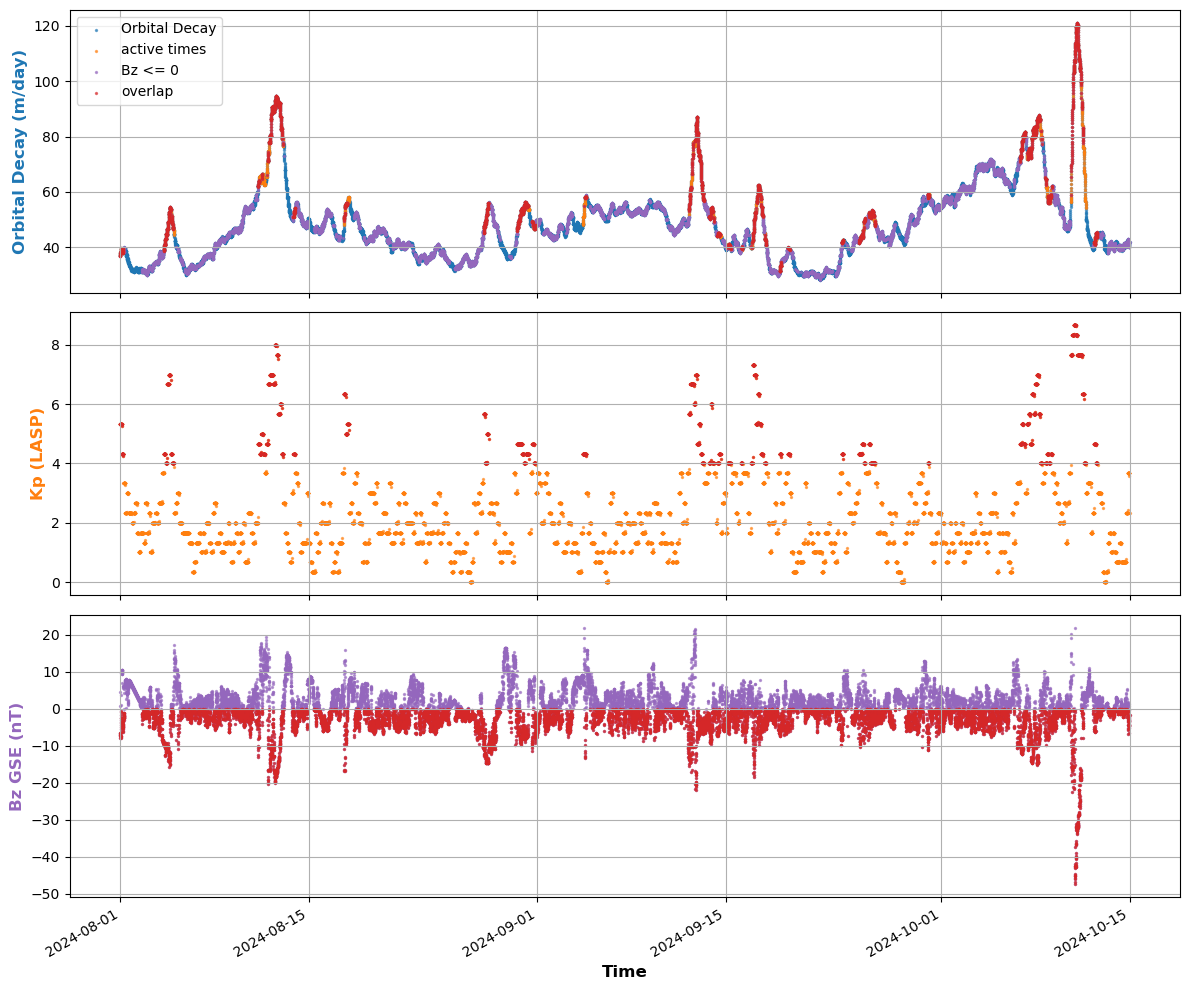

In [3]:
percent_active = (subset['Kp (LASP)'] >= 4).sum() / len(subset) * 100
print(f"Percentage of active times (Kp >= 4): {percent_active:.2f}%")
percent_Bz_negative = (subset['Bz GSE'] <= 0).sum() / len(subset) * 100
print(f"Percentage of times with Bz <= 0: {percent_Bz_negative:.2f}%")
print("overlap active times and Bz <= 0:",
      (subset[(subset['Kp (LASP)'] >= 4) & (subset['Bz GSE'] <= 0)].shape[0]) / len(subset) * 100)

active_times = subset[subset['Kp (LASP)'] >= 4].index
Bz_negative_times = subset[subset['Bz GSE'] <= 0].index
overlap_times = subset[(subset['Kp (LASP)'] >= 4) & (subset['Bz GSE'] <= 0)].index
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
axes[0].scatter(subset.index, subset['orbital_decay'], s=2, c='C0', alpha=0.6, label='Orbital Decay')
axes[0].scatter(subset.loc[active_times].index, subset.loc[active_times]['orbital_decay'], s=2, c='C1', alpha=0.6, label="active times")
axes[0].scatter(subset.loc[Bz_negative_times].index, subset.loc[Bz_negative_times]['orbital_decay'], s=2, c='C4', alpha=0.6, label="Bz <= 0")
axes[0].scatter(subset.loc[overlap_times].index, subset.loc[overlap_times]['orbital_decay'], s=2, c='C3', alpha=0.6, label="overlap")
axes[0].set_ylabel('Orbital Decay (m/day)', color='C0')
axes[0].grid(True)
axes[0].legend(loc = 'upper left')

axes[1].scatter(subset.index, subset['Kp (LASP)'], s=2, c='C1', alpha=0.6)
axes[1].scatter(subset[subset['Kp (LASP)'] >= 4].index, subset[subset['Kp (LASP)'] >= 4]['Kp (LASP)'], s=2, c='C3', alpha=0.6)
axes[1].set_ylabel('Kp (LASP)', color='C1')
axes[1].grid(True)

axes[2].scatter(subset.index, subset['Bz GSE'], s=2, c='C4', alpha=0.6)
axes[2].scatter(subset[subset['Bz GSE'] <= 0].index, subset[subset['Bz GSE'] <= 0]['Bz GSE'], s=2, c='C3', alpha=0.6)
axes[2].set_ylabel('Bz GSE (nT)', color='C4')
axes[2].set_xlabel('Time')
axes[2].grid(True)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

Based on this plot I think that Kp > 4 is the best indicator for events.

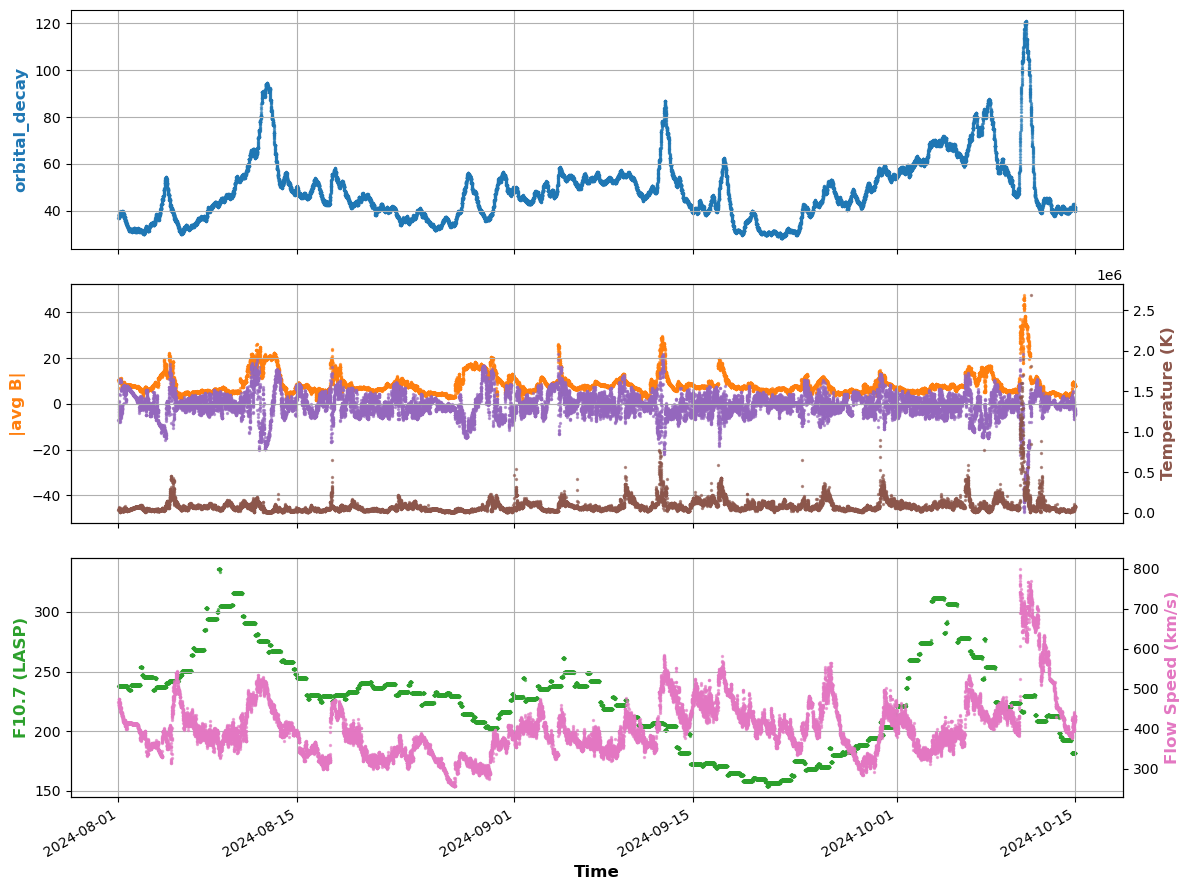

In [4]:
# plot all features from columns_needed
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].scatter(subset.index, subset['orbital_decay'], s=2, c='C0', alpha=0.6)
axes[0].set_ylabel('orbital_decay', color='C0')
axes[0].grid(True)

axes[1].scatter(subset.index, subset['|avg B|'], s=2, c='C1', alpha=0.6)
axes[1].scatter(subset.index, subset['Bz GSE'], s=2, c='C4', alpha=0.6)
axes[1].set_ylabel('|avg B|', color='C1')
axes[1].grid(True)
ax = axes[1].twinx()
ax.scatter(subset.index, subset['Temperature (K)'], s=2, c='C5', alpha=0.6)
ax.set_ylabel('Temperature (K)', color='C5')
ax.grid(False)

axes[2].scatter(subset.index, subset['F10.7 (LASP)'], s=2, c='C2', alpha=0.6)
axes[2].set_ylabel('F10.7 (LASP)', color='C2')
axes[2].set_xlabel('Time')
axes[2].grid(True)
ax = axes[2].twinx()
ax.scatter(subset.index, subset['Flow Speed (km/s'], s=2, c='C6', alpha=0.6)
ax.set_ylabel('Flow Speed (km/s)', color='C6')
ax.grid(False)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# 2. Prepare Data

## 2.1 Compute the orbital phase

In [5]:
from numpy.polynomial import Polynomial

p_list = [1.06605722e+02, -7.21846851e-09]
p = Polynomial(p_list)

orbital_period = p(subset.index.astype(np.int64) / 1e9) * 60 # seconds

# cumulative orbital cycles over time
cycles = np.cumsum(1 / orbital_period) * dt_seconds   # because your sampling is every 20s

# phase angle
subset["phase"] = (2 * np.pi * cycles) % (2 * np.pi)

subset["sin_phase"] = np.sin(subset.phase)
subset["cos_phase"] = np.cos(subset.phase)

In [6]:
from statsmodels.tsa.seasonal import STL

# assume regular sampling and compute period in samples:
mean_period_s = np.nanmedian(orbital_period)  # seconds per cycle
period_samples = int(round(mean_period_s / dt_seconds))
seasonal = 20 * period_samples + (20 * period_samples % 2 == 0) # Ensure odd
low_pass_jump = seasonal_jump = int(0.15 * (period_samples + 1))
trend_jump = int(0.15 * 1.5 * (period_samples + 1))

# stl = STL(subset["orbital_decay"], period=period_samples, robust=True)
stl = STL(
    subset["orbital_decay"],
    period=period_samples,
    seasonal=seasonal,
    seasonal_jump=seasonal_jump,
    trend_jump=trend_jump,
    low_pass_jump=low_pass_jump,
)
res = stl.fit()
subset["osc_stl"] = res.seasonal
subset["trend_stl"] = res.trend
subset["resid_stl"] = res.resid

# set variables
subset["oscillation"] = subset["osc_stl"] + subset["resid_stl"]
subset["trend"] = subset["trend_stl"]

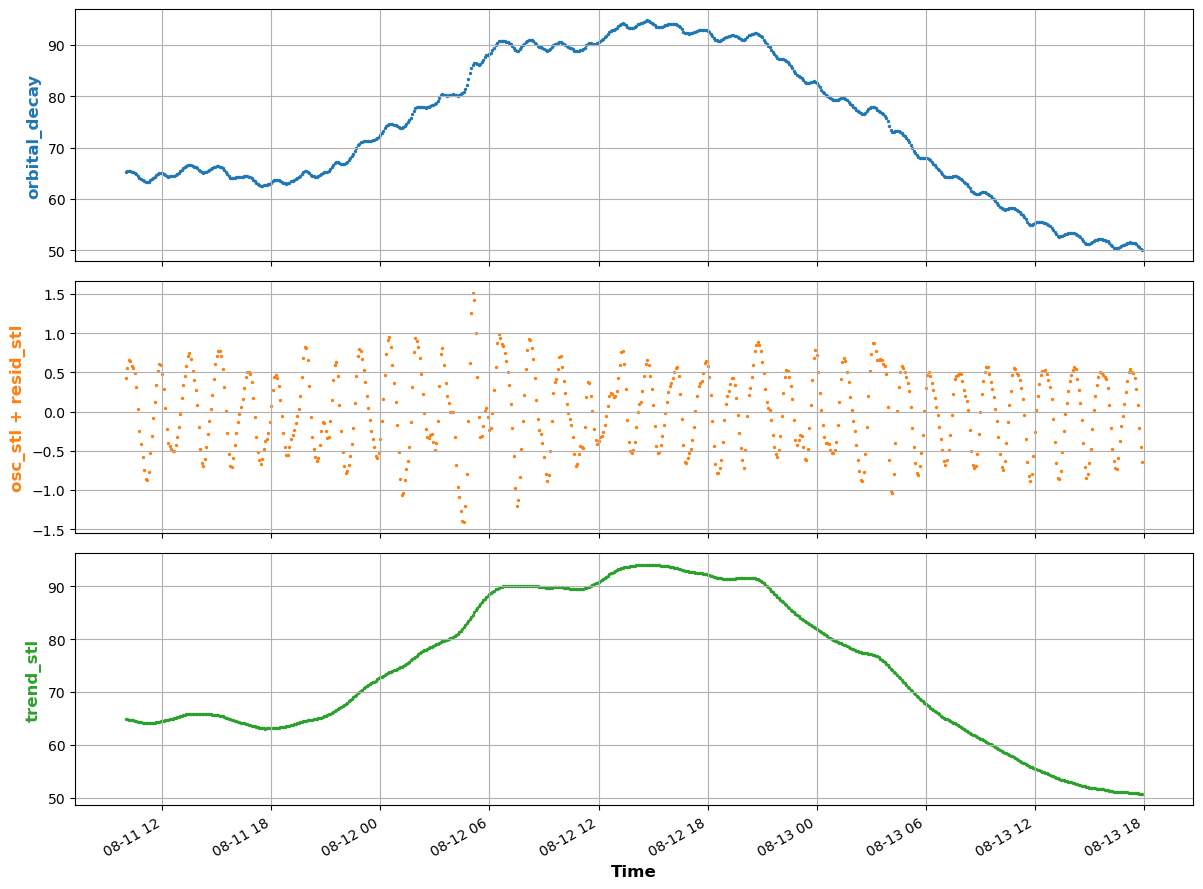

In [7]:
s_time = '2024-08-11 10:00:00'
e_time = '2024-08-13 18:00:00'
s_idx = subset.index.get_loc(s_time)
e_idx = subset.index.get_loc(e_time)
plot_subset = subset.iloc[s_idx:e_idx]
# plot all features from columns_needed
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].scatter(plot_subset.index, plot_subset['orbital_decay'], s=2, c='C0')
axes[0].set_ylabel('orbital_decay', color='C0')
axes[0].grid(True)

axes[1].scatter(plot_subset.index, plot_subset['osc_stl'] + plot_subset['resid_stl'], s=2, c='C1')
axes[1].set_ylabel('osc_stl + resid_stl', color='C1')
axes[1].grid(True)

axes[2].scatter(plot_subset.index, plot_subset['trend_stl'], s=2, c='C2')
# axes[2].plot(plot_subset.index, plot_subset['trend_stl'], c='C2', ls = '--', alpha=0.4)
axes[2].set_ylabel('trend_stl', color='C2')
axes[2].set_xlabel('Time')
axes[2].grid(True)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# 3 Multioutput Model


## 3.2 Predict the trend

In [8]:
hour = int(60 / (dt_seconds / 60))  # number of samples in one hour
lag_config_trend = {
    "od_daily_mean": {"lags": [24*hour, 7*24*hour]}, # we might not now the orbital decay rate, but we can estimate it from previous days
    "|avg B|": {'lags': list(range(1, 3*hour, np.max([hour//20, 1]))) + list(range(3*hour, 24*hour, hour))},
    "F10.7 (LASP)": {'lags': list(range(1, 24*hour, 6*hour)) + list(range(24*hour, 2*24*hour, 12*hour))},
    "Bz GSE": {'lags': list(range(1, 3*hour, np.max([hour//20, 1]))) + list(range(3*hour, 24*hour, hour))},
    "Flow Speed (km/s": {'lags': list(range(1, 3*hour, np.max([hour//20, 1]))) + list(range(3*hour, 24*hour, hour))},
    "Temperature (K)": {'lags': list(range(1, 3*hour, np.max([hour//20, 1]))) + list(range(3*hour, 24*hour, hour))},
}

X_trend = make_lags(subset, lag_config_trend)

n = 12  # hours ahead
y_stepsize = int(15 * (60 / dt_seconds)) # every 15 minutes
y_trend = make_multistep_target(subset[['trend']].copy(), steps=int(n * 60 * (60 / dt_seconds)), stepsize=y_stepsize)

# Shifting has created indexes that don't match. Only keep times for
na_mask = X_trend.isna().any(axis=1) | y_trend.isna().any(axis=1)
X_trend = X_trend[~na_mask]
y_trend = y_trend[~na_mask]

# Rename columns to avoid MultiIndex issues
X_trend.columns = ['_'.join(map(str, col)) if isinstance(col, tuple) else str(col) for col in X_trend.columns]

print("Number of input parameters for model:", X_trend.shape[1])
print("Number of output steps for model:", y_trend.shape[1])
print("Size of X:", X_trend.shape, ", size of y:", y_trend.shape)

Number of input parameters for model: 232
Number of output steps for model: 48
Size of X: (19444, 232) , size of y: (19444, 48)


In [9]:
from sklearn.linear_model import Lasso, LinearRegression, MultiTaskElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Train-test split (chronologically)
X_trend_train, X_trend_test, y_trend_train, y_trend_test = train_test_split(X_trend, y_trend, test_size=0.2, shuffle=False)

scaler = StandardScaler()
# scale and convert back to DataFrames
X_trend_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_trend_train),
    index=X_trend_train.index,
    columns=X_trend_train.columns
)

X_trend_test_scaled = pd.DataFrame(
    scaler.transform(X_trend_test),
    index=X_trend_test.index,
    columns=X_trend_test.columns
)

#----------------------------------------------------------------------------------------
# on Laptop for 2h forecast with 15 min stepsize for y
# LinearRegression took 2.8 seconds to run
# Lasso (alpha=0.01) took 2m 1s with similar (slightly worse) results
# MultiTaskElasticNet (alpha=0.1, max_iter=500) took 2m 41s
# (I also tried larger alpha values but results were worse even though computation was faster)
#----------------------------------------------------------------------------------------
# On AIUB computer for 12 hour forecast with 15 min stepsize for y
# LinearRegression took 2.1 seconds to run
# Lasso (alpha=0.01) took 16 minutes to run with similar results to LinearRegression
# MultiTaskElasticNet took 106 minutes with worse results than LinearRegression
#----------------------------------------------------------------------------------------
# model_trend = MultiTaskElasticNet(
#     alpha=0.01,
#     l1_ratio=0.2,
#     max_iter=2000
# )
model_trend = LinearRegression()

# Train only on active times
active_times = subset[subset['Kp (LASP)'] >= 4].index.intersection(X_trend_train_scaled.index)
model_trend.fit(
    X_trend_train_scaled.loc[active_times],
    y_trend_train.loc[active_times]
)

y_trend_fit = pd.DataFrame(model_trend.predict(X_trend_train_scaled), index=X_trend_train.index, columns=y_trend_train.columns)
y_trend_pred = pd.DataFrame(model_trend.predict(X_trend_test_scaled), index=X_trend_test.index, columns=y_trend_test.columns)

In [10]:
# save model
# import joblib
# joblib.dump(model_trend, 'Analysis/modeling/trend2_model_ElasticNet2.pkl')
# joblib.dump(scaler, 'Analysis/modeling/trend2_scaler2.pkl')

In [11]:
# load model
# import joblib
# model_trend = joblib.load('trend2_model_ElasticNet.pkl')
# scaler = joblib.load('trend2_scaler.pkl')

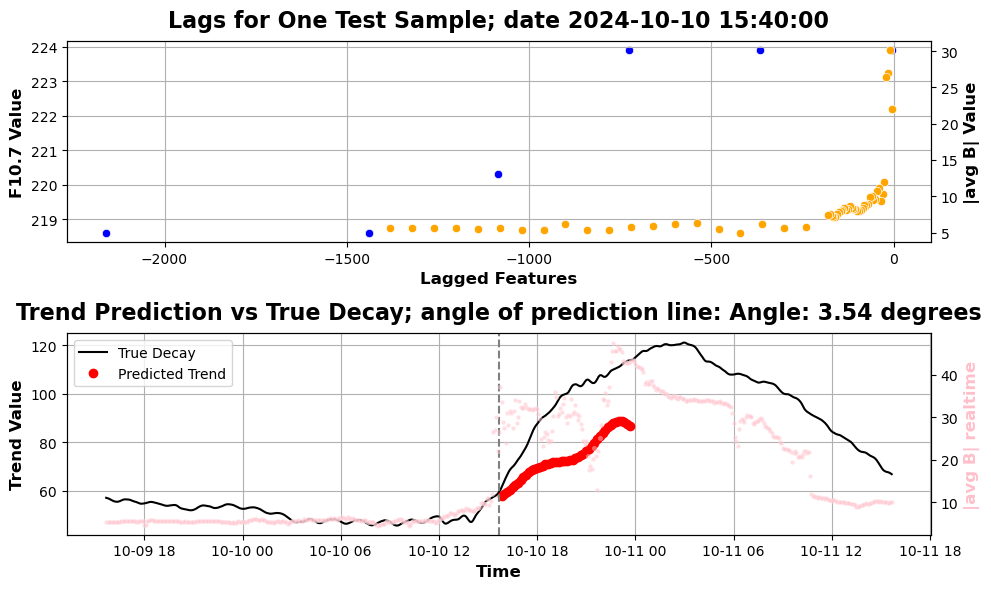

In [12]:
time = '2024-10-10 15:40:00'
idx = y_trend_test.index.get_loc(time)
sample_test = X_trend_test.iloc[idx]
sample_test_F, sample_test_B = sample_test.filter(like='F10.7'), sample_test.filter(like='|avg B|')
lag_times_F = [-int(col.split('_')[-1]) * dt_seconds / 60 for col in sample_test_F.index]
lag_times_B = [-int(col.split('_')[-1]) * dt_seconds / 60 for col in sample_test_B.index]
sample_test_F.index = lag_times_F
sample_test_B.index = lag_times_B   
sample_test_y = y_trend_test.iloc[idx]
lag_times_y = [int(col.split('_')[-1]) * dt_seconds / 60 for col in sample_test_y.index]

fig, ax = plt.subplots(figsize=(10, 6), nrows=2, ncols=1)
ax = ax.flatten()
sns.scatterplot(x=sample_test_F.index, y=sample_test_F.values, ax=ax[0], color='blue')
ax[0].set_title('Lags for One Test Sample; date '+ str(y_trend_test.iloc[idx].name))
plt.xlabel('Lagged Features')
ax[0].set_ylabel('F10.7 Value')
plt.grid(True)
sns.scatterplot(x=sample_test_B.index, y=sample_test_B.values, ax=ax[0].twinx(), color='orange')
ax[0].set_xlabel('Lagged Features')
plt.ylabel('|avg B| Value')
ax[0].grid(True)  

time_idx = y_trend_test.index[idx]
time_window = (time_idx - pd.Timedelta(hours=24), time_idx + pd.Timedelta(hours=24))
true_trend_window = subset.loc[time_window[0]:time_window[1], 'trend']
pred_trend = y_trend_pred.iloc[idx]
true_decay = subset.loc[time_window[0]:time_window[1], 'orbital_decay']
ax[1].plot(true_decay.index, true_decay.values, label='True Decay', color='black')
pred_times = [time_idx + pd.Timedelta(minutes=10 * (i + 1)) for i in range(len(pred_trend))]
ax[1].plot(pred_times, pred_trend.values, label='Predicted Trend', marker='o', linestyle='None', color='red')

angle = np.arctan2(pred_trend.values[-1] - pred_trend.values[0], (pred_times[-1] - pred_times[0]).total_seconds() / 60)
angle_deg = np.degrees(angle)
angle = f'Angle: {angle_deg:.2f} degrees'
ax[1].set_title(f'Trend Prediction vs True Decay; angle of prediction line: {angle}')
ax[1].set_xlabel('Time')
ax[1].set_ylabel('Trend Value')
ax[1].legend()

# overplot input B as background in ax[1]
bz_window = subset.loc[time_window[0]:time_window[1], '|avg B|']
ax2 = ax[1].twinx()
sns.scatterplot(x=bz_window.index, y=bz_window.values, ax=ax2, color='pink', alpha=0.5, s=10)
ax2.set_ylabel('|avg B| realtime', color='pink')

# add vline at test time index
ax[1].axvline(x=time_idx, color='gray', linestyle='--', label='Prediction Time')
ax[1].grid(True)
plt.tight_layout()

plt.show()  

Train RMSE: 11.2
Test RMSE: 13.4
Train R2: -0.145
Test R2: 0.333


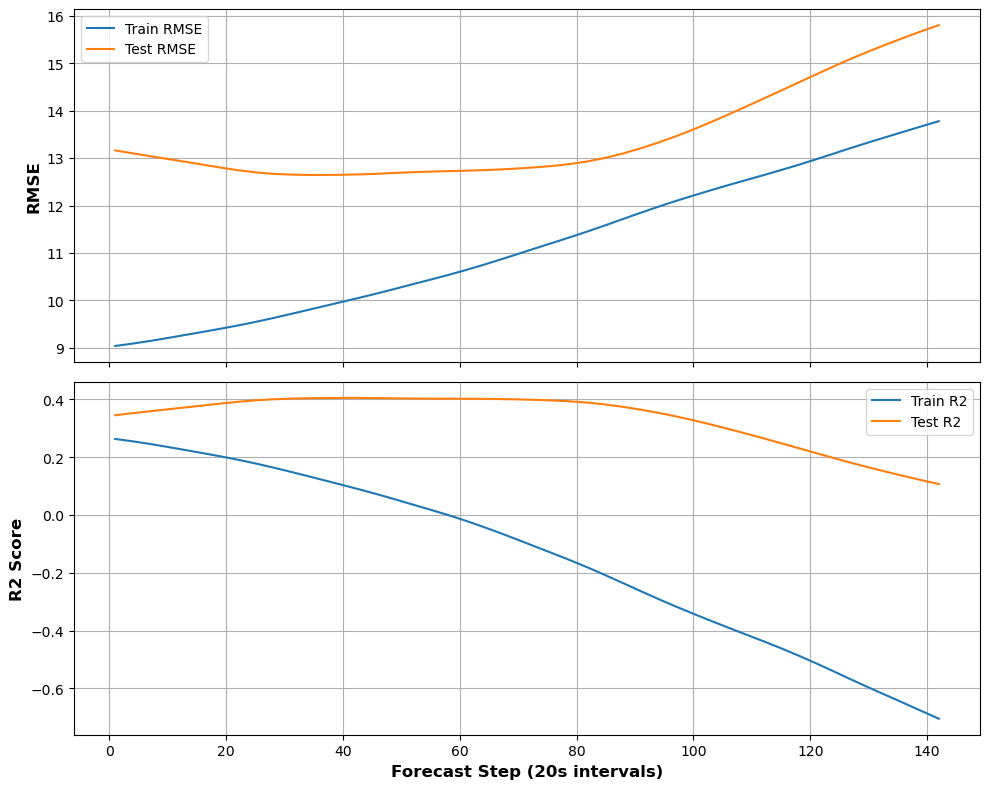

In [13]:
statistics(y_trend_train, y_trend_fit, y_trend_test, y_trend_pred)

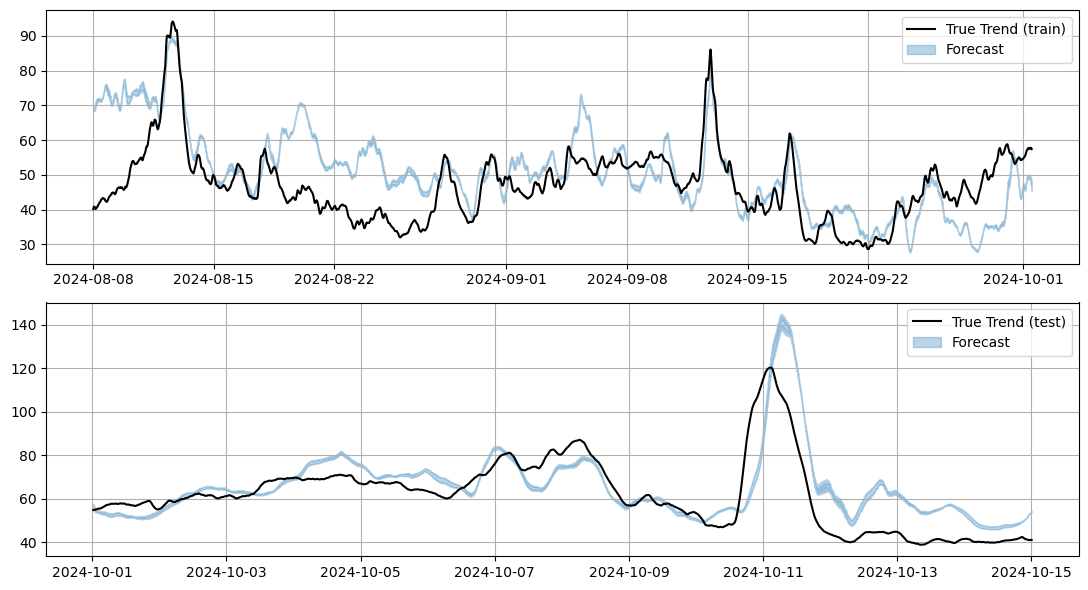

In [15]:
od_train = aggregate_multistep_predictions(y_trend_train, dt_seconds=dt_seconds, error_kind='sem')
od_test = aggregate_multistep_predictions(y_trend_test, dt_seconds=dt_seconds, error_kind='sem')
od_fit = aggregate_multistep_predictions(y_trend_fit, dt_seconds=dt_seconds, error_kind='sem')
od_pred = aggregate_multistep_predictions(y_trend_pred, dt_seconds=dt_seconds, error_kind='sem')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6))
ax1.plot(od_train.index, od_train['mean'], color='black')
ax1.fill_between(od_fit.index, od_fit['mean'] - od_fit['error'], od_fit['mean'] + od_fit['error'], color='C0', alpha=0.3)
_ = ax1.legend(['True Trend (train)', 'Forecast'])
ax1.grid(True)

# plot complete forecast horizon
ax2.plot(od_test.index, od_test['mean'], color='black')
ax2.fill_between(od_pred.index, od_pred['mean'] - od_pred['error'], od_pred['mean'] + od_pred['error'], color='C0', alpha=0.3)
_ = ax2.legend(['True Trend (test)', 'Forecast'])
ax2.grid(True)
plt.tight_layout()
plt.show()

## Summary

- works much better with difference, but still not great.